# Task 2: Customer Segmentation Using Unsupervised Learning

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [2]:
# Load Dataset
df = pd.read_csv(r"C:\Task 2\Mall_Customers.csv")

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [4]:
# Explore Dataset
df.shape

(200, 5)

In [5]:
df.columns

Index(['CustomerID', 'Genre', 'Age', 'Annual Income (k$)',
       'Spending Score (1-100)'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [7]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [8]:
df.isnull().sum()

CustomerID                0
Genre                     0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

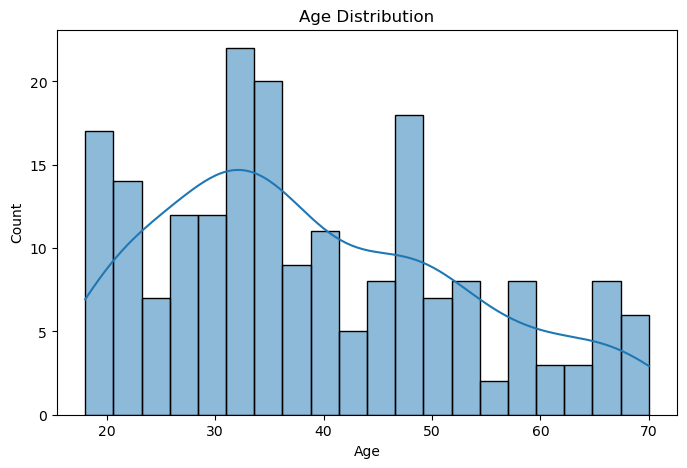

In [9]:
# Age Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

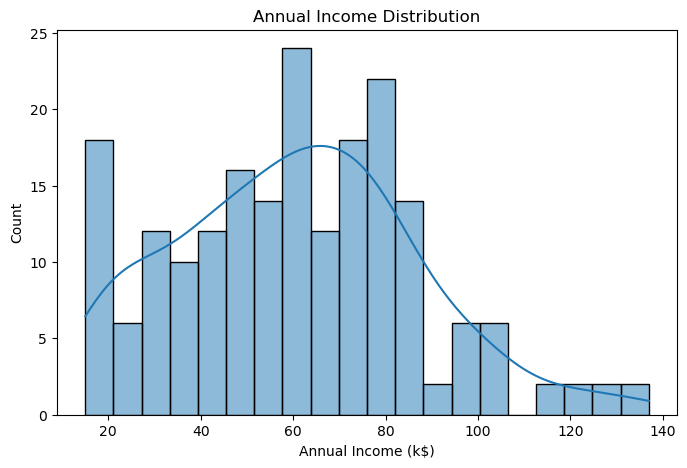

In [10]:
# Annual Income Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Annual Income (k$)"], bins=20, kde=True)

plt.title("Annual Income Distribution")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Count")

plt.show()

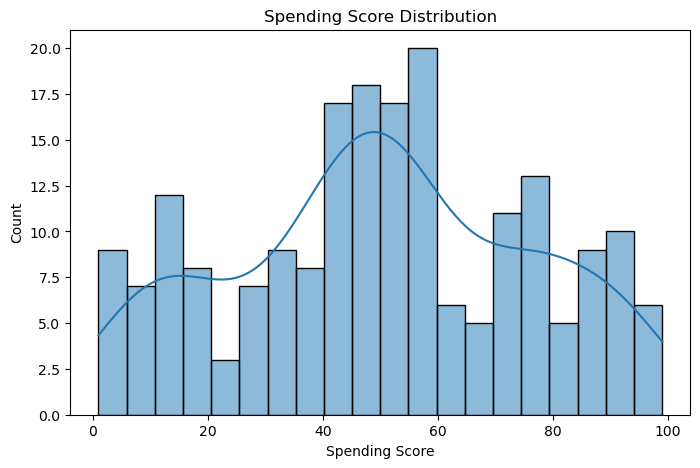

In [11]:
# Spending Score Distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Spending Score (1-100)"], bins=20, kde=True)

plt.title("Spending Score Distribution")
plt.xlabel("Spending Score")
plt.ylabel("Count")

plt.show()

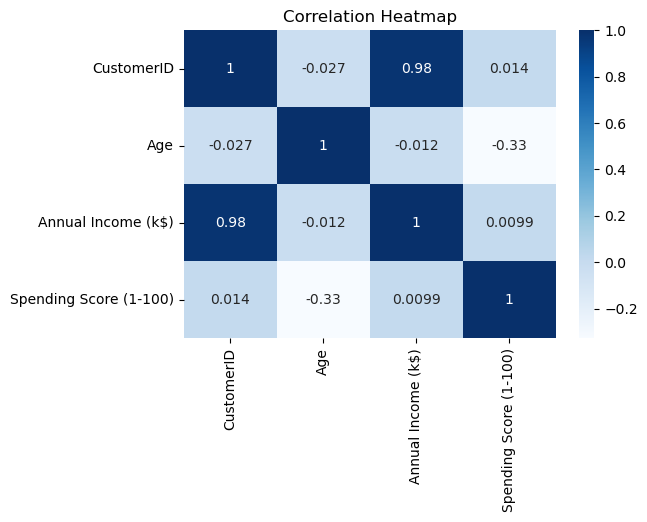

In [12]:
# Correlation Heatmap
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(6,4))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")

plt.title("Correlation Heatmap")

plt.show()

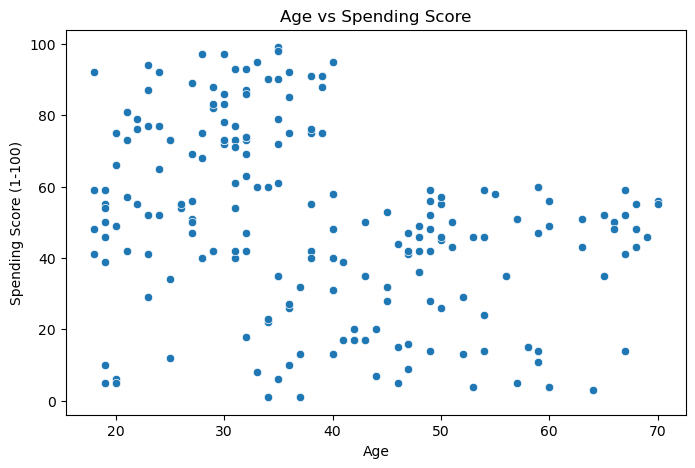

In [13]:
# Age vs Spending Score
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Age",
    y="Spending Score (1-100)"
)

plt.title("Age vs Spending Score")

plt.show()

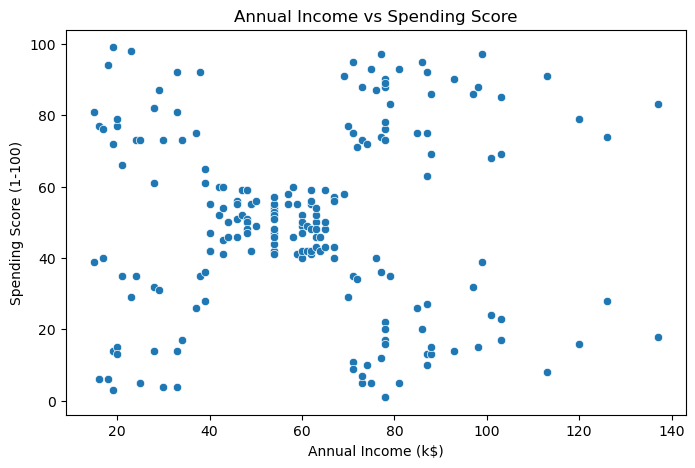

In [14]:
# Annual Income vs Spending Score
plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df,
    x="Annual Income (k$)",
    y="Spending Score (1-100)"
)

plt.title("Annual Income vs Spending Score")

plt.show()

In [15]:
# Encode Categorical Features
le = LabelEncoder()

df["Genre"] = le.fit_transform(df["Genre"])

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [16]:
# Select Features
X = df.drop("CustomerID", axis=1)

X.head()

,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [17]:
# Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [19]:
# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

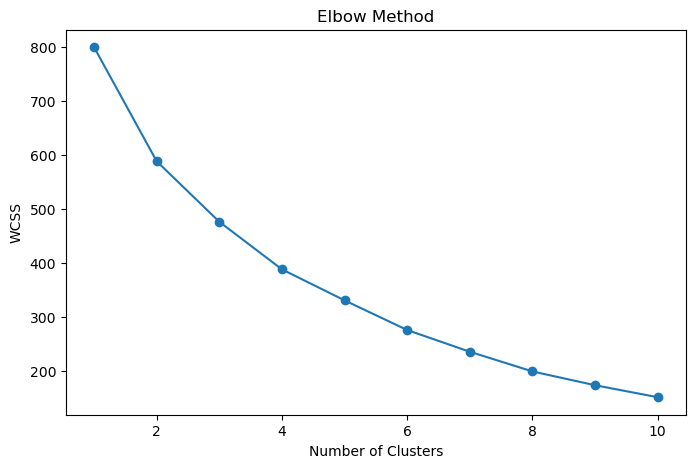

In [20]:
# Elbow Method
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker="o")

plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")

plt.show()

In [21]:
# Train K-Means Model
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,1,19,15,39,3
1,2,1,21,15,81,3
2,3,0,20,16,6,3
3,4,0,23,16,77,3
4,5,0,31,17,40,3


In [22]:
# Cluster Distribution
df["Cluster"].value_counts()

Cluster
3    54
2    43
0    39
4    35
1    29
Name: count, dtype: int64

In [26]:
# Cluster Analysis
df.groupby("Cluster").mean(numeric_only=True)

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,,,
0,162.000000,0.461538,32.692308,86.538462,82.128205
1,165.482759,0.448276,36.482759,89.517241,18.000000
2,73.651163,0.000000,49.813953,49.232558,40.069767
3,52.814815,0.407407,24.907407,39.722222,61.203704
4,84.685714,1.000000,55.714286,53.685714,36.771429


In [28]:
# PCA for Cluster Visualization
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

In [29]:
# Create PCA DataFrame
pca_df = pd.DataFrame(X_pca, columns=["PCA1", "PCA2"])

pca_df["Cluster"] = clusters

pca_df.head()

,PCA1,PCA2,Cluster
0,-0.406383,-0.520714,3
1,-1.427673,-0.367310,3
2,0.050761,-1.894068,3
3,-1.694513,-1.631908,3
4,-0.313108,-1.810483,3


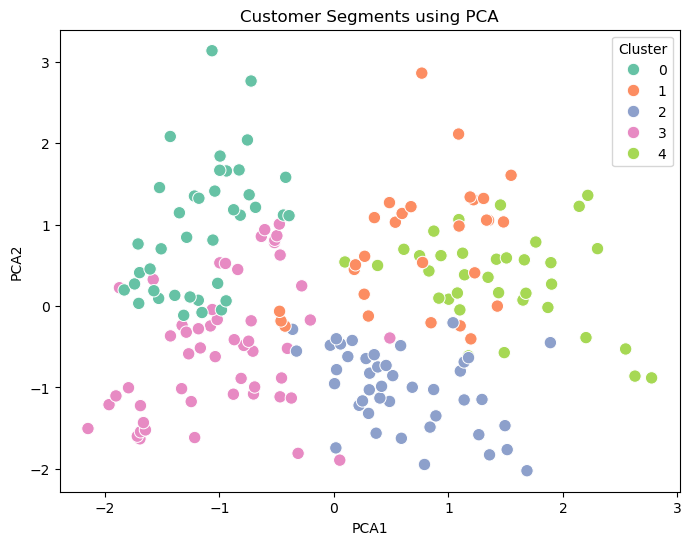

In [30]:
# Visualize Clusters
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=pca_df,
    x="PCA1",
    y="PCA2",
    hue="Cluster",
    palette="Set2",
    s=80
)

plt.title("Customer Segments using PCA")

plt.show()

# Marketing Strategies

- **Cluster 0:** Target these customers with premium products and exclusive membership offers.
- **Cluster 1:** Offer discounts and promotional campaigns to increase customer engagement.
- **Cluster 2:** Recommend personalized products and loyalty rewards to encourage repeat purchases.
- **Cluster 3:** Focus on retaining loyal customers through exclusive benefits and special offers.
- **Cluster 4:** Promote budget-friendly products and seasonal discounts to increase spending.

# Conclusion

This project successfully applied K-Means clustering to segment customers based on their demographic and spending characteristics. Exploratory Data Analysis (EDA) was performed to understand the dataset, and PCA was used to visualize the customer clusters effectively. The identified customer segments provide valuable insights that can help businesses design targeted marketing strategies, improve customer engagement, and support data-driven decision-making.